# Análise de Resultados - PUMA FL
Este notebook processa as múltiplas simulações (runs) geradas pelo servidor e plota as curvas de performance comparando diferentes estratégias, exibindo o intervalo de confiança (desvio padrão).

In [36]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Configuração de estilo para gráficos nível artigo acadêmico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5
})

# Caminho padrão para a pasta de resultados (ajuste se necessário)
RESULTS_DIR = "../results/"

In [37]:
def load_strategy_results(dataset, strategy, algo="FedAVG", prune="withou_Prune"):
    """
    Busca os arquivos h5 gerados pelo servidor e calcula média e desvio padrão.
    """
    pattern = os.path.join(RESULTS_DIR, f"{dataset}_{strategy}_{prune}_{algo}_run*.h5")
    files = glob.glob(pattern)
    
    if not files:
        print(f"⚠️ Nenhum arquivo encontrado para: {pattern}")
        return None
        
    print(f"✅ Encontrados {len(files)} arquivos para o padrão: {dataset}_{strategy}_{prune}_{algo}")
    
    acc_runs, loss_runs, mb_runs, mb_bruto_runs, time_runs, size_runs = [], [], [], [], [], []
    
    for f in files:
        with h5py.File(f, 'r') as hf:
            acc_runs.append(np.array(hf['rs_test_acc']))
            loss_runs.append(np.array(hf['rs_train_loss']))
            mb_runs.append(np.array(hf['sended_model_Mb']))
            mb_bruto_runs.append(np.array(hf['Sended_without_quant']))
            time_runs.append(np.array(hf['Round_time']))
            
            # Nova extração com suporte a retrocompatibilidade (arquivos antigos não quebram)
            if 'Model_size_per_round_Mb' in hf:
                size_runs.append(np.array(hf['Model_size_per_round_Mb']))
            
    resultados = {
        'acc_mean': np.mean(acc_runs, axis=0), 'acc_std': np.std(acc_runs, axis=0),
        'loss_mean': np.mean(loss_runs, axis=0), 'loss_std': np.std(loss_runs, axis=0),
        'mb_mean': np.mean(mb_runs, axis=0), 'mb_std': np.std(mb_runs, axis=0),
        'mb_bruto_mean': np.mean(mb_bruto_runs, axis=0), 'mb_bruto_std': np.std(mb_bruto_runs, axis=0),
        'time_mean': np.mean(time_runs, axis=0), 'time_std': np.std(time_runs, axis=0),
    }
    
    if size_runs:
        resultados['size_mean'] = np.mean(size_runs, axis=0)
        resultados['size_std'] = np.std(size_runs, axis=0)
        
    return resultados

In [38]:
DATASET = "OxfordPets"

print("Carregando resultados do Servidor...")

dados_sora = load_strategy_results(
    dataset=DATASET, 
    strategy="sora_with_schedule",
    algo="FedAVG",
    prune="prune"
)

dados_lora = load_strategy_results(
    dataset=DATASET, 
    strategy="lora",
    algo="FedAVG",
    prune="prune"
)

Carregando resultados do Servidor...
✅ Encontrados 1 arquivos para o padrão: OxfordPets_sora_with_schedule_prune_FedAVG
✅ Encontrados 1 arquivos para o padrão: OxfordPets_lora_prune_FedAVG


### 1. Desempenho do Modelo (Acurácia Global)

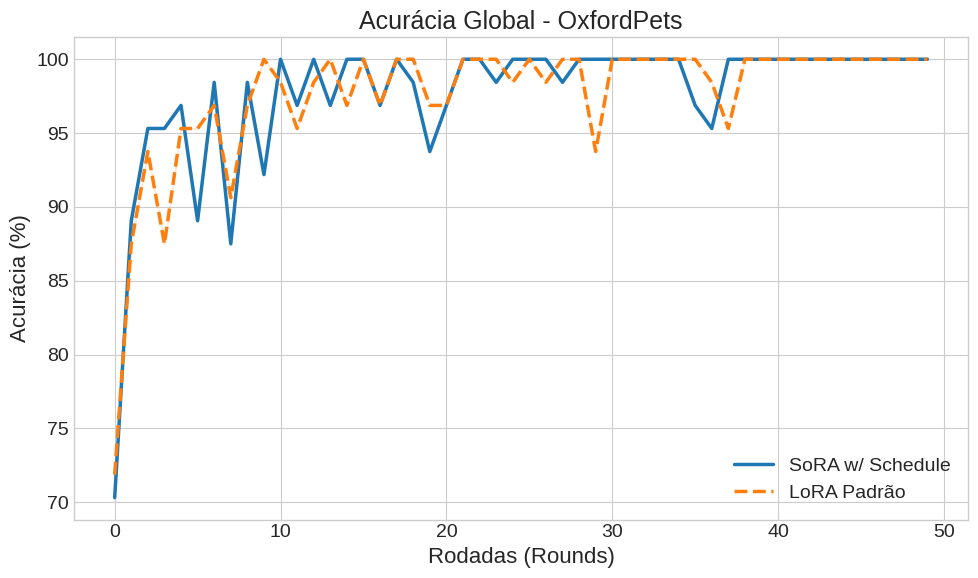

In [39]:
plt.figure(figsize=(10, 6))

if dados_sora:
    plt.plot(dados_sora['acc_mean'], label='SoRA w/ Schedule', color='#1f77b4')
    plt.fill_between(range(len(dados_sora['acc_mean'])), 
                     dados_sora['acc_mean'] - dados_sora['acc_std'], 
                     dados_sora['acc_mean'] + dados_sora['acc_std'], color='#1f77b4', alpha=0.15)

if dados_lora:
    plt.plot(dados_lora['acc_mean'], label='LoRA Padrão', color='#ff7f0e', linestyle='--')
    plt.fill_between(range(len(dados_lora['acc_mean'])), 
                     dados_lora['acc_mean'] - dados_lora['acc_std'], 
                     dados_lora['acc_mean'] + dados_lora['acc_std'], color='#ff7f0e', alpha=0.15)

plt.title(f"Acurácia Global - {DATASET}")
plt.xlabel("Rodadas (Rounds)")
plt.ylabel("Acurácia (%)")
plt.legend()
plt.tight_layout()
plt.show()

### 2. Custo de Comunicação Acumulado (Megabytes)

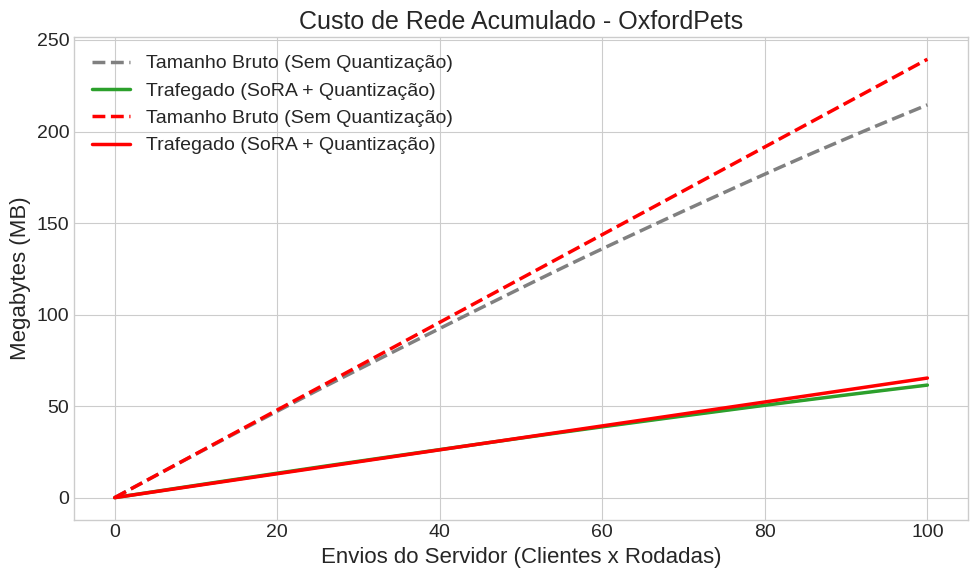

In [40]:
plt.figure(figsize=(10, 6))

if dados_sora:
    eixo_x = range(len(dados_sora['mb_mean']))
    
    # Linha mostrando o tamanho se enviasse o modelo bruto
    plt.plot(eixo_x, dados_sora['mb_bruto_mean'], label='Tamanho Bruto (Sem Quantização)', color='gray', linestyle='--')
    
    # Linha mostrando o que foi efetivamente trafegado com o SoRA
    plt.plot(eixo_x, dados_sora['mb_mean'], label='Trafegado (SoRA + Quantização)', color='#2ca02c')
    
    # Intervalo de confiança
    plt.fill_between(eixo_x, 
                     dados_sora['mb_mean'] - dados_sora['mb_std'], 
                     dados_sora['mb_mean'] + dados_sora['mb_std'], 
                     color='#2ca02c', alpha=0.15)

if dados_lora:
    eixo_x = range(len(dados_lora['mb_mean']))
    
    # Linha mostrando o tamanho se enviasse o modelo bruto
    plt.plot(eixo_x, dados_lora['mb_bruto_mean'], label='Tamanho Bruto (Sem Quantização)', color='red', linestyle='--')
    
    # Linha mostrando o que foi efetivamente trafegado com o SoRA
    plt.plot(eixo_x, dados_lora['mb_mean'], label='Trafegado (SoRA + Quantização)', color='red')
    
    # Intervalo de confiança
    plt.fill_between(eixo_x, 
                     dados_lora['mb_mean'] - dados_lora['mb_std'], 
                     dados_lora['mb_mean'] + dados_lora['mb_std'], 
                     color='#2ca02c', alpha=0.15)

plt.title(f"Custo de Rede Acumulado - {DATASET}")
# Correção do Rótulo do Eixo X para refletir a lógica de 1 envio por cliente
plt.xlabel("Envios do Servidor (Clientes x Rodadas)")
plt.ylabel("Megabytes (MB)")
plt.legend()
plt.tight_layout()
plt.show()

### 3. Latência de Treinamento (Tempo)

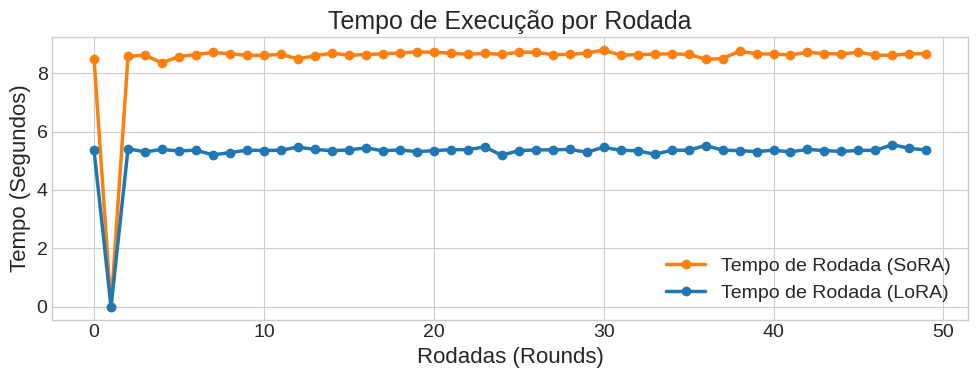

In [41]:
plt.figure(figsize=(10, 4))

if dados_sora:
    eixo_x = range(len(dados_sora['time_mean']))
    plt.plot(eixo_x, dados_sora['time_mean'], label='Tempo de Rodada (SoRA)', color='#ff7f0e', marker='o')
    
    plt.fill_between(eixo_x, 
                     dados_sora['time_mean'] - dados_sora['time_std'], 
                     dados_sora['time_mean'] + dados_sora['time_std'], 
                     color='#ff7f0e', alpha=0.15)
    
if dados_lora:
    eixo_x = range(len(dados_lora['time_mean']))
    plt.plot(eixo_x, dados_lora['time_mean'], label='Tempo de Rodada (LoRA)', color='#1f77b4', marker='o')
    
    plt.fill_between(eixo_x, 
                     dados_lora['time_mean'] - dados_lora['time_std'], 
                     dados_lora['time_mean'] + dados_lora['time_std'], 
                     color='#1f77b4', alpha=0.15)

plt.title("Tempo de Execução por Rodada")
plt.xlabel("Rodadas (Rounds)")
plt.ylabel("Tempo (Segundos)")
plt.legend()
plt.tight_layout()
plt.show()

### 4. Tamanho do Modelo por Rodada (Efeito SoRA)

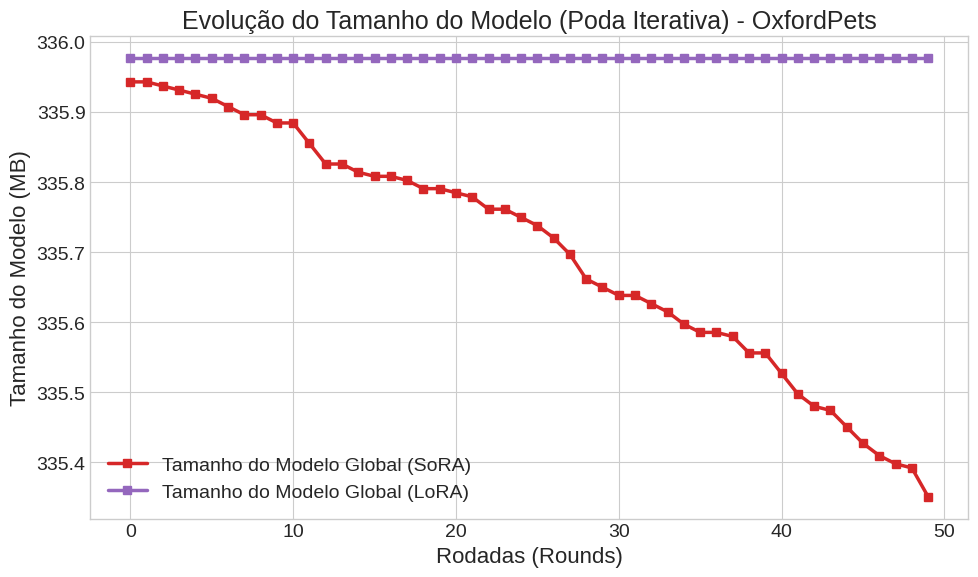

In [42]:
plt.figure(figsize=(10, 6))

if dados_sora and 'size_mean' in dados_sora:
    eixo_x = range(len(dados_sora['size_mean']))
    plt.plot(eixo_x, dados_sora['size_mean'], label='Tamanho do Modelo Global (SoRA)', color='#d62728', marker='s')
    
    plt.fill_between(eixo_x, 
                     dados_sora['size_mean'] - dados_sora['size_std'], 
                     dados_sora['size_mean'] + dados_sora['size_std'], 
                     color='#d62728', alpha=0.15)

    plt.title(f"Evolução do Tamanho do Modelo (Poda Iterativa) - {DATASET}")
    plt.xlabel("Rodadas (Rounds)")
    plt.ylabel("Tamanho do Modelo (MB)")
    plt.legend()
    plt.tight_layout()
    
    if dados_lora and 'size_mean' in dados_lora:
        eixo_x = range(len(dados_lora['size_mean']))
        plt.plot(eixo_x, dados_lora['size_mean'], label='Tamanho do Modelo Global (LoRA)', color='#9467bd', marker='s')
        
        plt.fill_between(eixo_x, 
                         dados_lora['size_mean'] - dados_lora['size_std'], 
                         dados_lora['size_mean'] + dados_lora['size_std'], 
                         color='#9467bd', alpha=0.15)
        
        plt.title(f"Evolução do Tamanho do Modelo (Poda Iterativa) - {DATASET}")
        plt.xlabel("Rodadas (Rounds)")
        plt.ylabel("Tamanho do Modelo (MB)")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("⚠️ Dados de 'Model_size_per_round_Mb' não encontrados nos arquivos h5.")
    print("Certifique-se de que a simulação foi executada com o server.py atualizado.")